In [50]:
%load_ext autoreload
%autoreload 2
from autodq import AutoDQ

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
project = AutoDQ(
    "../datasets/sample/sales.csv",
)


In [52]:
project.add_dataset(
    name="customers",
    dataset_path="../datasets/sample/customers.csv",
)

project.list_datasets()



=== AutoDQ Dataset Registry ===

Dataset: main
  Path: ../datasets/sample/sales.csv
  Rows: 5035
  Columns: 23
  Primary: Yes

Dataset: customers
  Path: ../datasets/sample/customers.csv
  Rows: 3849
  Columns: 6
  Primary: No



In [53]:
merged = project.merge_datasets(
    left="main",
    right="customers",
    output_name="sales_with_customers",
    on="Customer_ID",
    how="left",
    validate="many_to_one",
    suffixes=("", "_customer"),
    make_active=True,
)

project.show_merge_report()

print("\nMerged Dataset Preview:")
print(merged.head())

print("\nMerged Dataset Shape:")
print(merged.shape)


=== AutoDQ Merge Report ===

Left Dataset: main
Right Dataset: customers
Join Type: left
Join Columns: Customer_ID
Detected Relationship: many_to_one

Rows:
  Left: 5035
  Right: 3849
  Output: 5035
  Change: +0
  Expanded Rows: 0

Matching:
  Matched Left Rows: 5035
  Unmatched Left Rows: 0

Duplicate Keys:
  Left: 1186
  Right: 0

Merged Dataset Preview:
   Transaction_ID        Date Customer_ID  Customer_Age  Gender  \
0          102255  2026-04-20   CUST-6241          40.0  Female   
1          102237  2025-02-21   CUST-8166          31.0  Female   
2          101405  2024-01-03   CUST-6631          34.0    Male   
3          101523  2024-02-25   CUST-5038          52.0  Female   
4          102503  2024-05-06   CUST-8697          39.0  Female   

  Customer_Segment   Region         City Sales_Channel Payment_Method  ...  \
0          Regular    South       London        Online    Credit Card  ...   
1          Student  Central  Mississauga    Mobile App    Credit Card  ...   
2  

In [54]:
print("\nFirst 5 Rows:")
print(project.head())

print("\nLast 5 Rows:")
print(project.tail())

print("\nRandom Sample:")
print(project.sample(3))

project.info()


First 5 Rows:
   Transaction_ID        Date Customer_ID  Customer_Age  Gender  \
0          102255  2026-04-20   CUST-6241          40.0  Female   
1          102237  2025-02-21   CUST-8166          31.0  Female   
2          101405  2024-01-03   CUST-6631          34.0    Male   
3          101523  2024-02-25   CUST-5038          52.0  Female   
4          102503  2024-05-06   CUST-8697          39.0  Female   

  Customer_Segment   Region         City Sales_Channel Payment_Method  ...  \
0          Regular    South       London        Online    Credit Card  ...   
1          Student  Central  Mississauga    Mobile App    Credit Card  ...   
2          Regular  Central    Kitchener        Online           Cash  ...   
3          Premium     West    Vancouver  Retail Store  Bank Transfer  ...   
4          Regular     East      Toronto  Retail Store           Cash  ...   

     Cost  Profit  Delivery_Days  Returned  Customer_Satisfaction  \
0   69.89   19.22              4         0  

In [55]:
project.set_type(
    column="Date",
    dtype="datetime",
)

project.set_target("Revenue")

In [56]:

project.apply_knowledge()
project.show_knowledge()



=== AutoDQ Knowledge Layer ===

Date
  Semantic Type: datetime
  Preferred Imputation: do_not_impute_without_context
  Preferred Outlier Strategy: None
  Notes: Date fields should be parsed as datetime.

Customer_Age
  Semantic Type: continuous_numeric
  Preferred Imputation: median
  Preferred Outlier Strategy: domain_range_check
  Expected Min: 0
  Expected Max: 120
  Allow Negative: False
  Notes: Age usually falls between 0 and 120.

Gender
  Semantic Type: categorical
  Preferred Imputation: mode
  Preferred Outlier Strategy: None
  Notes: Gender is usually a low-cardinality categorical field.

Region
  Semantic Type: geographic_category
  Preferred Imputation: mode
  Preferred Outlier Strategy: None
  Notes: Region is usually a categorical location field.

Product_Category
  Semantic Type: product_category
  Preferred Imputation: mode
  Preferred Outlier Strategy: None
  Notes: Product is usually a categorical business field.

Product
  Semantic Type: product_category
  Preferre

In [57]:

project.profile()
project.show_profile()


=== AutoDQ Dataset Profile ===
Dataset: sales_with_customers.in_memory
Rows: 5035
Columns: 28
Duplicate rows: 33

Column Groups:
Numeric: ['Transaction_ID', 'Customer_Age', 'Quantity', 'Unit_Price', 'Gross_Sales', 'Discount_Rate', 'Discount_Amount', 'Revenue', 'Cost', 'Profit', 'Delivery_Days', 'Returned', 'Customer_Satisfaction', 'Customer_Age_customer']
Categorical: ['Customer_ID', 'Gender', 'Customer_Segment', 'Region', 'City', 'Sales_Channel', 'Payment_Method', 'Product_Category', 'Product', 'Gender_customer', 'Customer_Segment_customer', 'Region_customer', 'City_customer']
Datetime: ['Date']

Columns:
- Transaction_ID | type: int64 | semantic: identifier | missing: 0 (0.0%)
- Date | type: datetime64[us] | semantic: datetime | missing: 0 (0.0%)
- Customer_ID | type: str | semantic: unknown | missing: 0 (0.0%)
- Customer_Age | type: float64 | semantic: continuous_numeric | missing: 127 (2.52%)
- Gender | type: str | semantic: unknown | missing: 0 (0.0%)
- Customer_Segment | type: s

In [58]:
project.statistics()
project.show_statistics()



=== AutoDQ Statistics ===

Customer_Age
  Mean: 35.94233903830481
  Median: 36.0
  Std: 11.246544037680632
  Skewness: 0.4479092855792217
  Kurtosis: 0.7824874303858929
  Missing: 127
  Distribution: approximately_normal
  Skewness Level: approximately_symmetric
  Tail Risk: low_tail_risk
  Confidence: 75.0%
  Explanation: Customer_Age appears to follow a approximately_normal. Skewness is 0.448, indicating approximately_symmetric. Kurtosis is 0.782, suggesting low_tail_risk.

Quantity
  Mean: 2.857994041708044
  Median: 2.0
  Std: 4.19545002375571
  Skewness: 17.14183724737351
  Kurtosis: 408.87537433373825
  Missing: 0
  Distribution: right_skewed_distribution
  Skewness Level: highly_right_skewed
  Tail Risk: high_tail_risk
  Confidence: 95.0%
  Explanation: Quantity appears to follow a right_skewed_distribution. Skewness is 17.142, indicating highly_right_skewed. Kurtosis is 408.875, suggesting high_tail_risk.

Unit_Price
  Mean: 243.79670109235354
  Median: 75.13
  Std: 409.098243

In [59]:

project.interpret()
project.show_interpretations()



=== AutoDQ Statistical Interpretations ===

Quantity
  Insight: mean_median_gap
  Severity: medium
  Message: The mean is substantially above the median, suggesting an asymmetric distribution.
  Evidence:
    - Mean = 2.858
    - Median = 2.0
    - Relative gap = 42.9%
  Downstream Implications:
    - Mean-based summaries may be misleading.
    - Median may be more robust for imputation.
    - Distribution-sensitive models may require transformation.
  Confidence: 85.0%

  Insight: skewness
  Severity: high
  Message: Quantity appears right-skewed. Large values may be pulling the mean upward.
  Evidence:
    - Skewness = 17.1418
    - Distribution type = right_skewed_distribution
  Downstream Implications:
    - Median is preferred over mean for imputation.
    - Consider transformation before linear modeling.
    - Pearson correlation may be less reliable.
    - Outlier review is recommended.
  Confidence: 90.0%

  Insight: heavy_tail
  Severity: high
  Message: Quantity has heavy-ta

In [60]:
project.recommend()
project.show_recommendations()


=== AutoDQ Cleaning Recommendations ===

1. missing_values
   Strategy: median
   Priority: low
   Action: Apply median strategy to Customer_Age.
   Reason: Diagnosis detected missing values in Customer_Age. Knowledge rule 'age' recommends median imputation. Statistics show mean=35.9423 and median=36.0.
   Affected Columns: Customer_Age
   Risk: Incorrect imputation may introduce bias or distort the distribution.
   Confidence: 88.0%

2. missing_values
   Strategy: mode
   Priority: low
   Action: Apply mode strategy to Region.
   Reason: Diagnosis detected missing values in Region. Knowledge rule 'region' recommends mode imputation.
   Affected Columns: Region
   Risk: Incorrect imputation may introduce bias or distort the distribution.
   Confidence: 80.0%

3. missing_values
   Strategy: review_missing_values
   Priority: low
   Action: Apply review_missing_values strategy to City.
   Reason: Diagnosis detected missing values in City.
   Affected Columns: City
   Risk: Incorrect imp

In [61]:
project.decide()

DecisionPlan(actions=[DecisionAction(action_id=1, issue_type='missing_values', strategy='median', affected_columns=['Customer_Age'], action='Apply median strategy to Customer_Age.', reason="Diagnosis detected missing values in Customer_Age. Knowledge rule 'age' recommends median imputation. Statistics show mean=35.9423 and median=36.0.", priority='low', risk='Incorrect imputation may introduce bias or distort the distribution.', confidence=0.88, status='pending'), DecisionAction(action_id=2, issue_type='missing_values', strategy='mode', affected_columns=['Region'], action='Apply mode strategy to Region.', reason="Diagnosis detected missing values in Region. Knowledge rule 'region' recommends mode imputation.", priority='low', risk='Incorrect imputation may introduce bias or distort the distribution.', confidence=0.8, status='pending'), DecisionAction(action_id=3, issue_type='missing_values', strategy='review_missing_values', affected_columns=['City'], action='Apply review_missing_value

In [62]:
project.preview()
project.show_preview()


=== AutoDQ Cleaning Preview ===

Action 1: missing_values
Strategy: median
Preview:
  Customer_Age:
    Missing before: 127
    Suggested action: Column-specific imputation or removal
    Sample values: ['40.0', '31.0', '34.0', '52.0', '39.0']

Action 2: missing_values
Strategy: mode
Preview:
  Region:
    Missing before: 75
    Suggested action: Column-specific imputation or removal
    Sample values: ['South', 'Central', 'Central', 'West', 'East']

Action 3: missing_values
Strategy: review_missing_values
Preview:
  City:
    Missing before: 60
    Suggested action: Column-specific imputation or removal
    Sample values: ['London', 'Mississauga', 'Kitchener', 'Vancouver', 'Toronto']

Action 4: missing_values
Strategy: median
Preview:
  Revenue:
    Missing before: 30
    Suggested action: Column-specific imputation or removal
    Sample values: ['89.11', '284.09', '31.98', '199.58', '209.53']

Action 5: missing_values
Strategy: median
Preview:
  Customer_Satisfaction:
    Missing be

In [63]:
project.approve_all()

In [64]:
project.clean()
project.show_cleaning_report()

project.validate_cleaning()
project.show_validation()


=== AutoDQ Cleaning Report ===

Actions processed: 20
Successful actions: 9

Action 1: missing_values
  Strategy: median
  Status: success
  Message: Applied median missing-value handling.
  Affected Columns: Customer_Age
  Rows before: 5035
  Rows after: 5035

Action 2: missing_values
  Strategy: mode
  Status: success
  Message: Applied mode missing-value handling.
  Affected Columns: Region
  Rows before: 5035
  Rows after: 5035

Action 3: missing_values
  Strategy: review_missing_values
  Status: success
  Message: Applied review_missing_values missing-value handling.
  Affected Columns: City
  Rows before: 5035
  Rows after: 5035

Action 4: missing_values
  Strategy: median
  Status: success
  Message: Applied median missing-value handling.
  Affected Columns: Revenue
  Rows before: 5035
  Rows after: 5035

Action 5: missing_values
  Strategy: median
  Status: success
  Message: Applied median missing-value handling.
  Affected Columns: Customer_Satisfaction
  Rows before: 5035
 

In [65]:
project.correlation()
project.show_correlation()


=== AutoDQ Correlation Intelligence ===

Relationships found: 17
Target relationships found: 6

Target Relationships:

- Gross_Sales → Revenue
  Correlation: 0.9977
  Strength: very_strong
  Direction: positive
  Interpretation: Gross_Sales has a very strong positive relationship with Revenue. Higher Gross_Sales values tend to align with higher Revenue values.
  Recommendation: Gross_Sales may be an important predictor of Revenue. Review for possible target leakage before modelling.
  Confidence: 95.0%

- Cost → Revenue
  Correlation: 0.6961
  Strength: moderate
  Direction: positive
  Interpretation: Cost has a moderate positive relationship with Revenue. Higher Cost values tend to align with higher Revenue values.
  Recommendation: Cost may provide useful predictive signal for Revenue.
  Confidence: 82.0%

- Unit_Price → Revenue
  Correlation: 0.6934
  Strength: moderate
  Direction: positive
  Interpretation: Unit_Price has a moderate positive relationship with Revenue. Higher Unit

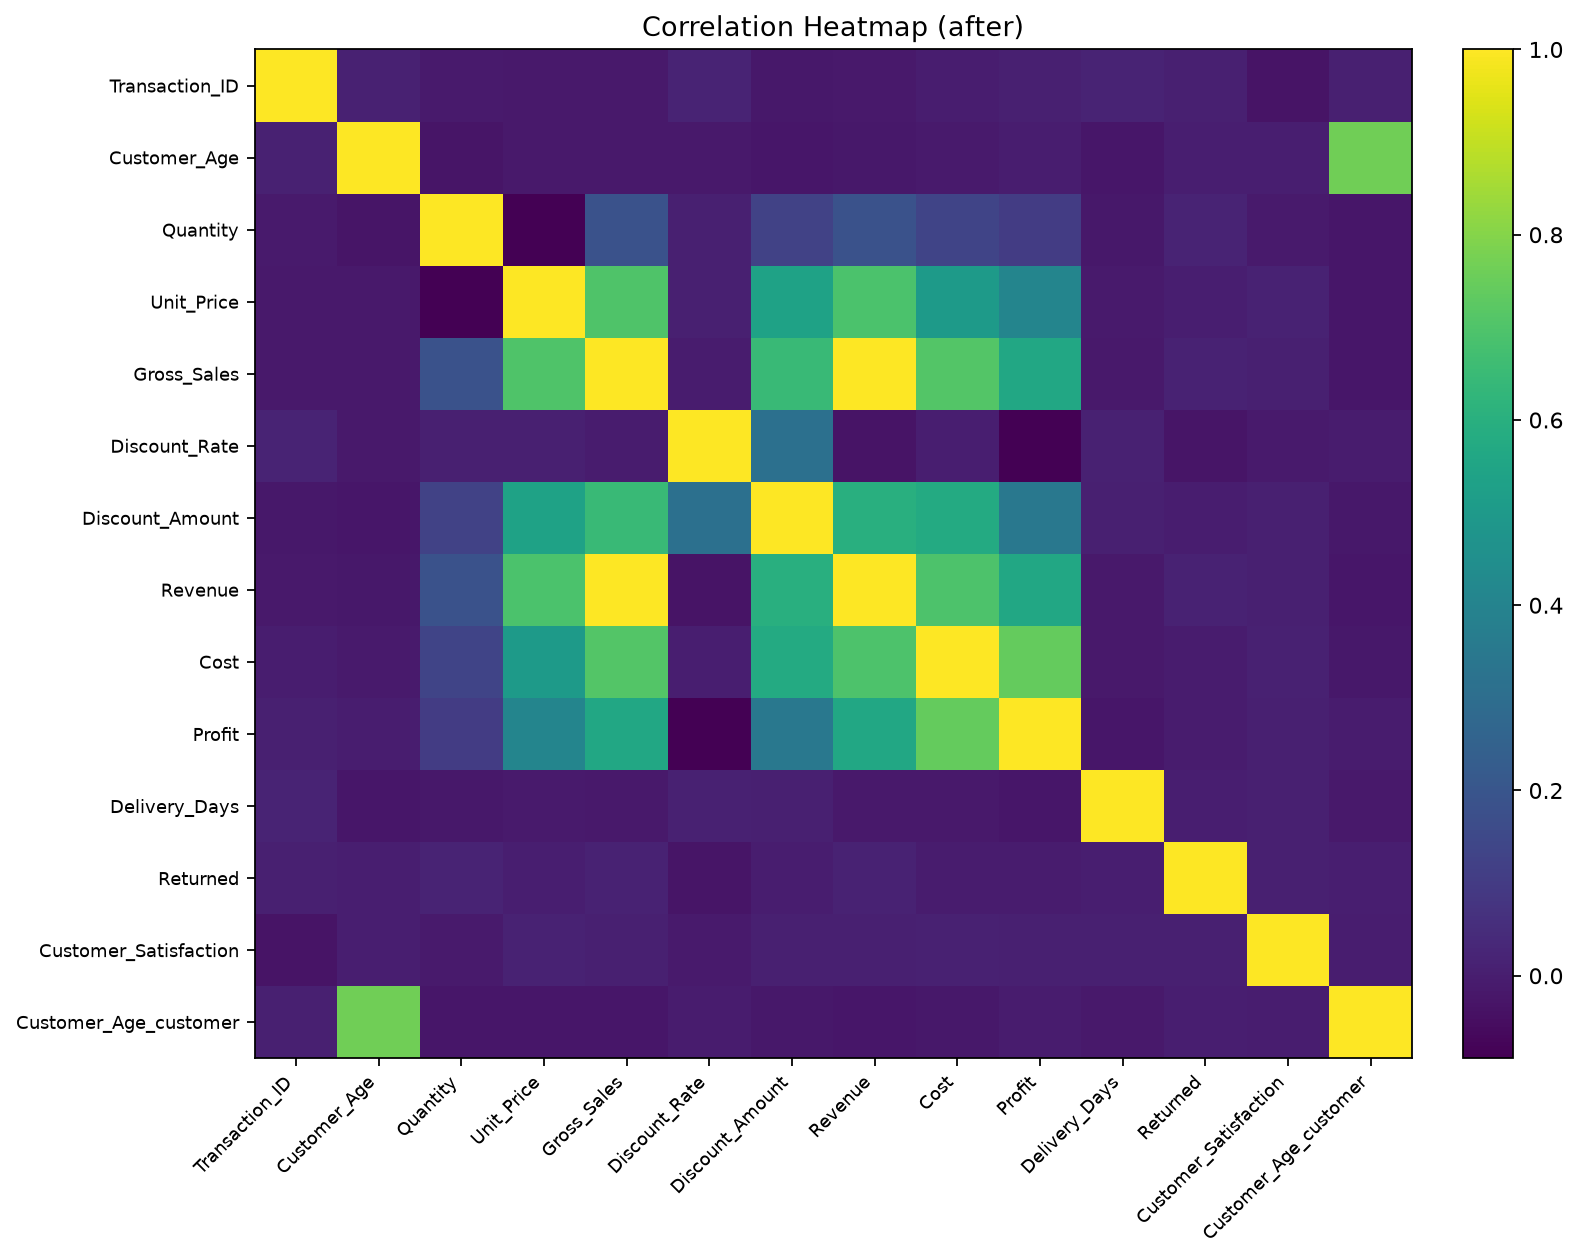

VisualizationReport(charts=[VisualizationSpec(chart_id='correlation_heatmap_after', chart_type='correlation_heatmap', title='Correlation Heatmap (after)', description='Shows pairwise correlation between numeric variables.', data=[{'feature': 'Transaction_ID', 'Transaction_ID': 1.0, 'Customer_Age': 0.013, 'Quantity': -0.01, 'Unit_Price': -0.013, 'Gross_Sales': -0.015, 'Discount_Rate': 0.02, 'Discount_Amount': -0.019, 'Revenue': -0.014, 'Cost': -0.002, 'Profit': 0.006, 'Delivery_Days': 0.02, 'Returned': 0.005, 'Customer_Satisfaction': -0.03, 'Customer_Age_customer': 0.008}, {'feature': 'Customer_Age', 'Transaction_ID': 0.013, 'Customer_Age': 1.0, 'Quantity': -0.028, 'Unit_Price': -0.016, 'Gross_Sales': -0.016, 'Discount_Rate': -0.014, 'Discount_Amount': -0.021, 'Revenue': -0.017, 'Cost': -0.012, 'Profit': 0.0, 'Delivery_Days': -0.021, 'Returned': 0.003, 'Customer_Satisfaction': 0.004, 'Customer_Age_customer': 0.762}, {'feature': 'Quantity', 'Transaction_ID': -0.01, 'Customer_Age': -0.028

In [66]:
project.visualize(
    chart="correlation_heatmap",
    stage="after",
)

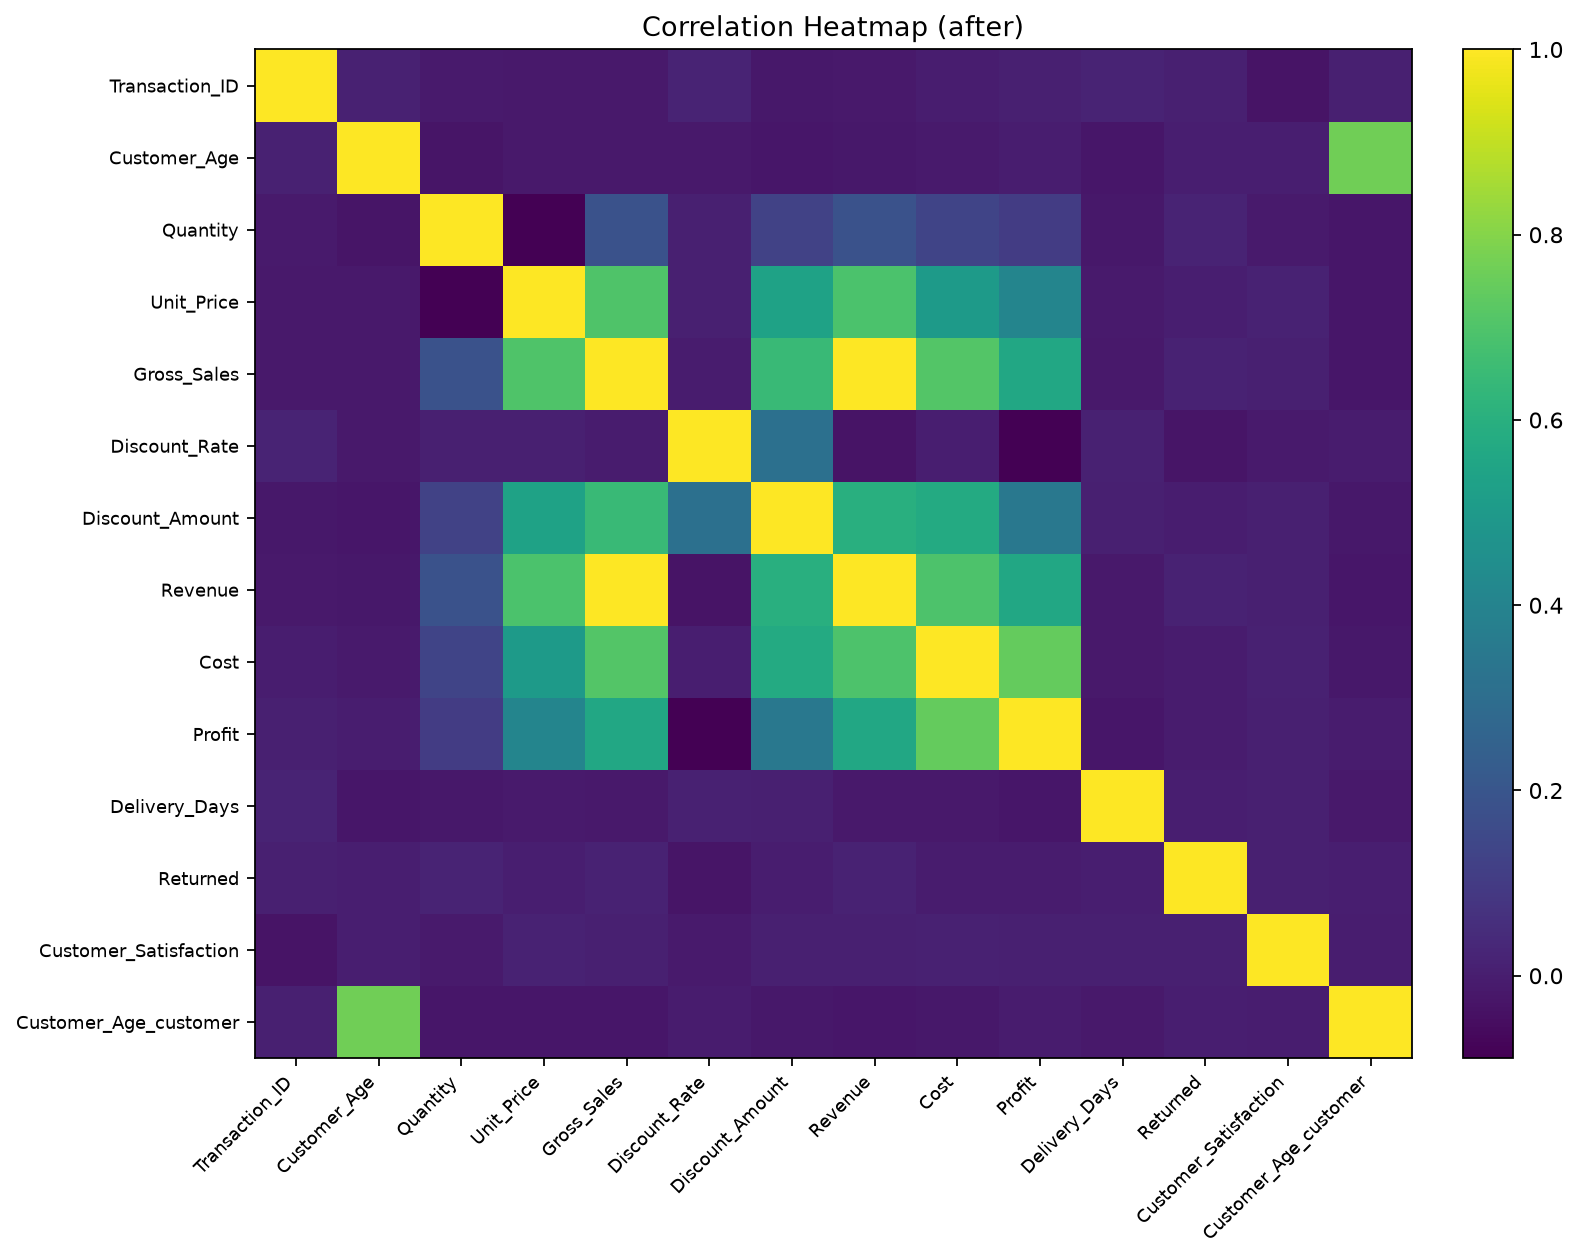


=== AutoDQ Visualizations ===

Charts generated: 1

- Correlation Heatmap (after)
  ID: correlation_heatmap_after
  Type: correlation_heatmap
  Stage: after
  X: None
  Y: None
  Recommended: True
  Data points: 14
  Description: Shows pairwise correlation between numeric variables.


In [67]:
project.show_visualizations()

In [68]:
project.ml_readiness()
project.show_ml_readiness()



=== AutoDQ Machine Learning Readiness ===

Readiness Score: 91.89/100
Target: Revenue
Target Type: continuous_numeric
Recommended Task: regression

Recommended Models:
- Random Forest Regressor
- Gradient Boosting Regressor
- Linear Regression with preprocessing
- XGBoost/LightGBM Regressor

Strengths:
- Dataset has enough rows for basic machine learning experimentation.
- 14 numeric feature(s) available.
- 13 categorical/text feature(s) available.
- Target column is set to 'Revenue'.

Readiness Issues:

- [MEDIUM] missing_values
  Message: 634 missing values detected.
  Recommendation: Handle missing values before training models.
  Confidence: 95.0%

- [MEDIUM] duplicate_rows
  Message: 33 duplicate row(s) detected.
  Recommendation: Remove duplicates unless repeated records are valid events.
  Confidence: 90.0%

- [LOW] categorical_encoding_required
  Message: Categorical columns must be encoded before most ML models.
  Recommendation: Use one-hot encoding, ordinal encoding, target

In [69]:
project.model(
    algorithm="decision_tree_regressor",
    use_engineered=False,
)

project.predict()

report = project.explain(
    max_rows=50,
    use_engineered=False,
)

print(report.method)
print(report.has_shap_artifacts)
print(report.shap_artifacts.feature_names)

shap_tree_explainer
True
['Transaction_ID', 'Customer_Age', 'Quantity', 'Unit_Price', 'Gross_Sales', 'Discount_Rate', 'Discount_Amount', 'Cost', 'Profit', 'Delivery_Days', 'Returned', 'Customer_Satisfaction', 'Customer_Age_customer', 'Customer_ID_CUST-1000', 'Customer_ID_CUST-1010', 'Customer_ID_CUST-1013', 'Customer_ID_CUST-1015', 'Customer_ID_CUST-1020', 'Customer_ID_CUST-1022', 'Customer_ID_CUST-1023', 'Customer_ID_CUST-1024', 'Customer_ID_CUST-1026', 'Customer_ID_CUST-1027', 'Customer_ID_CUST-1030', 'Customer_ID_CUST-1031', 'Customer_ID_CUST-1037', 'Customer_ID_CUST-1039', 'Customer_ID_CUST-1042', 'Customer_ID_CUST-1043', 'Customer_ID_CUST-1045', 'Customer_ID_CUST-1046', 'Customer_ID_CUST-1049', 'Customer_ID_CUST-1053', 'Customer_ID_CUST-1057', 'Customer_ID_CUST-1065', 'Customer_ID_CUST-1066', 'Customer_ID_CUST-1071', 'Customer_ID_CUST-1072', 'Customer_ID_CUST-1081', 'Customer_ID_CUST-1082', 'Customer_ID_CUST-1085', 'Customer_ID_CUST-1088', 'Customer_ID_CUST-1090', 'Customer_ID_CUS

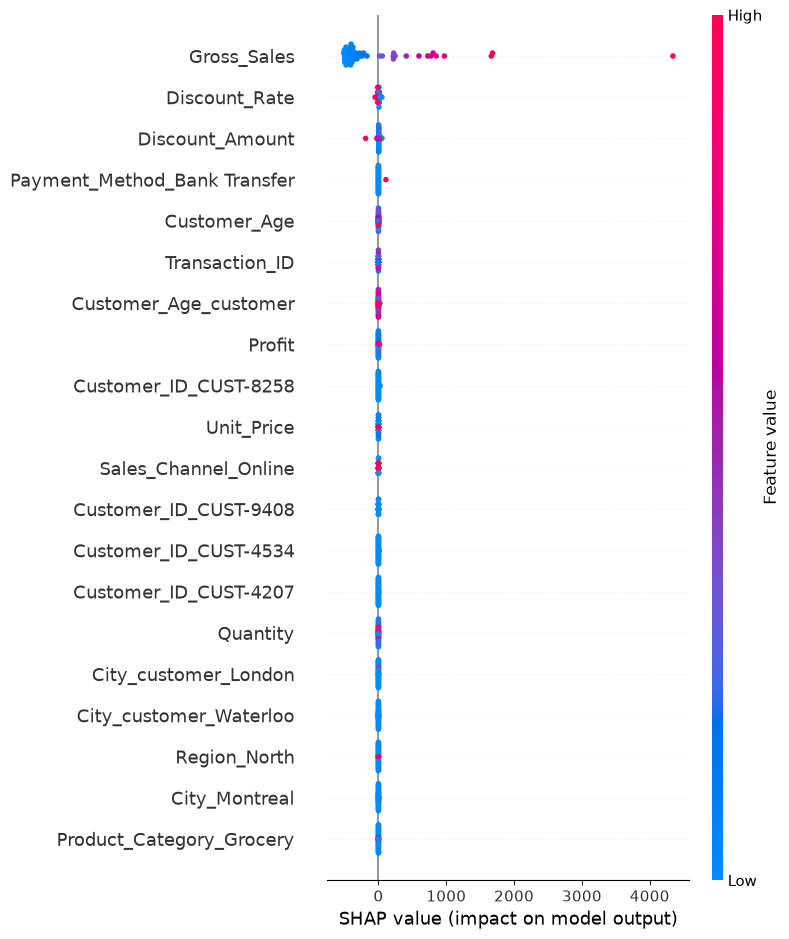

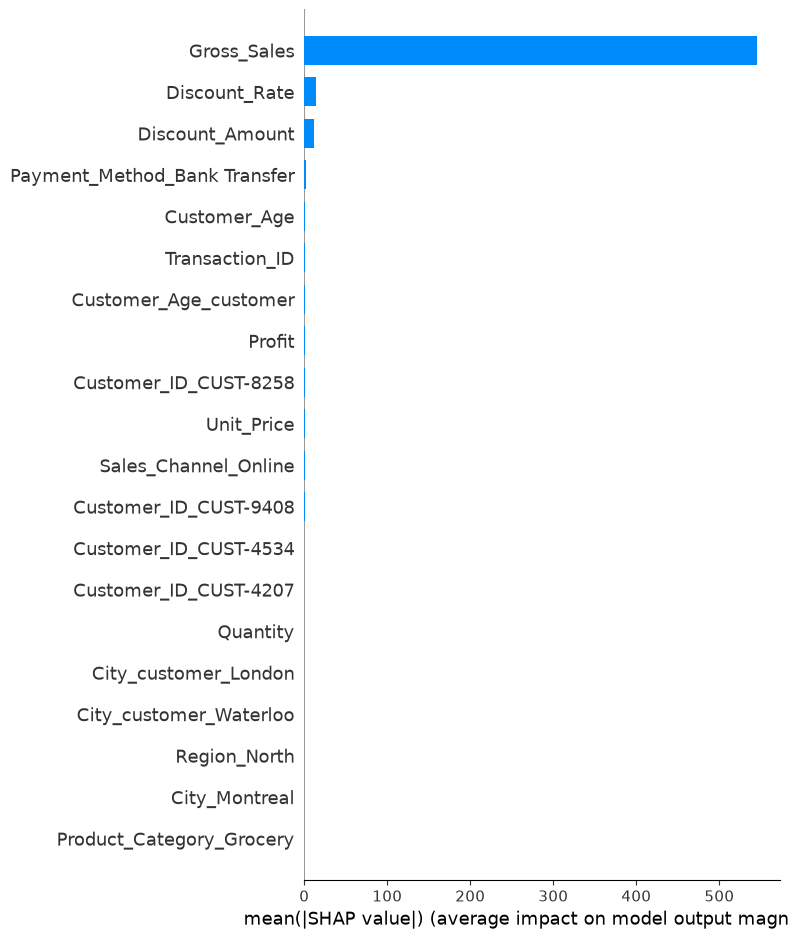

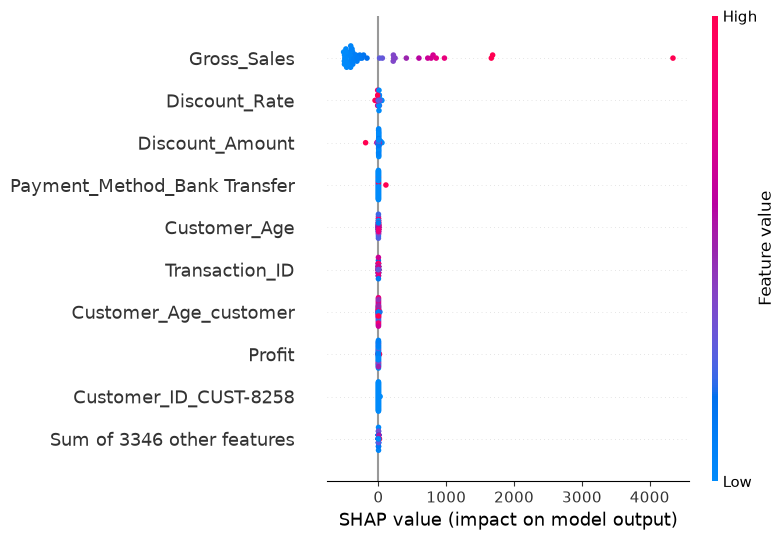

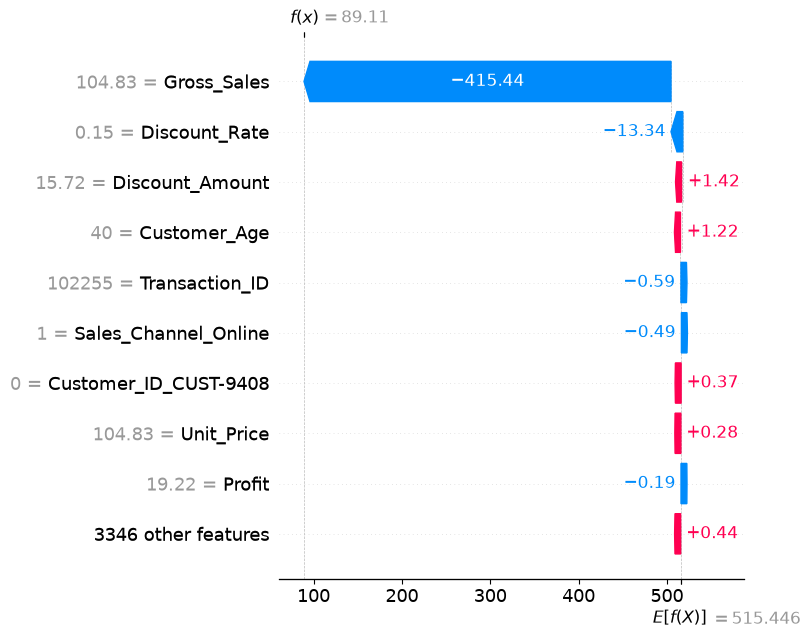

<Figure size 640x480 with 0 Axes>

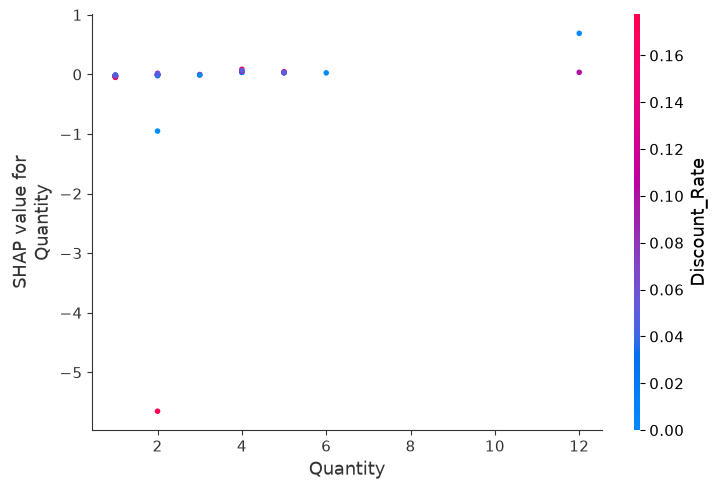

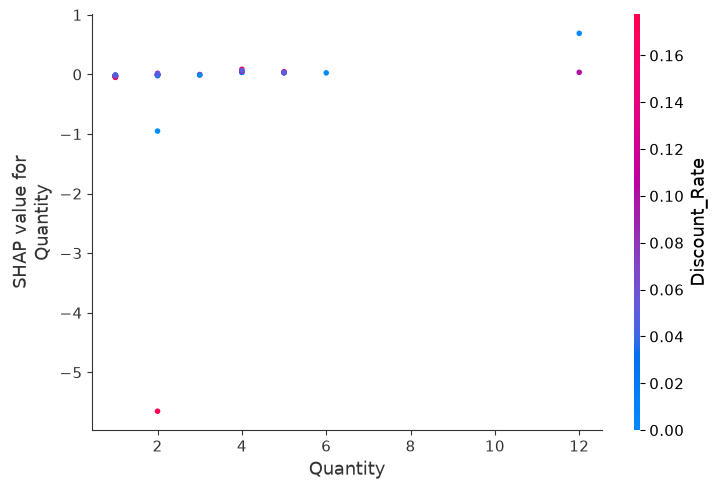

In [70]:
project.visualize_shap("summary")
project.visualize_shap("bar")
project.visualize_shap("beeswarm")
project.visualize_shap("waterfall", row=0)
project.visualize_shap("dependence", feature="Quantity")



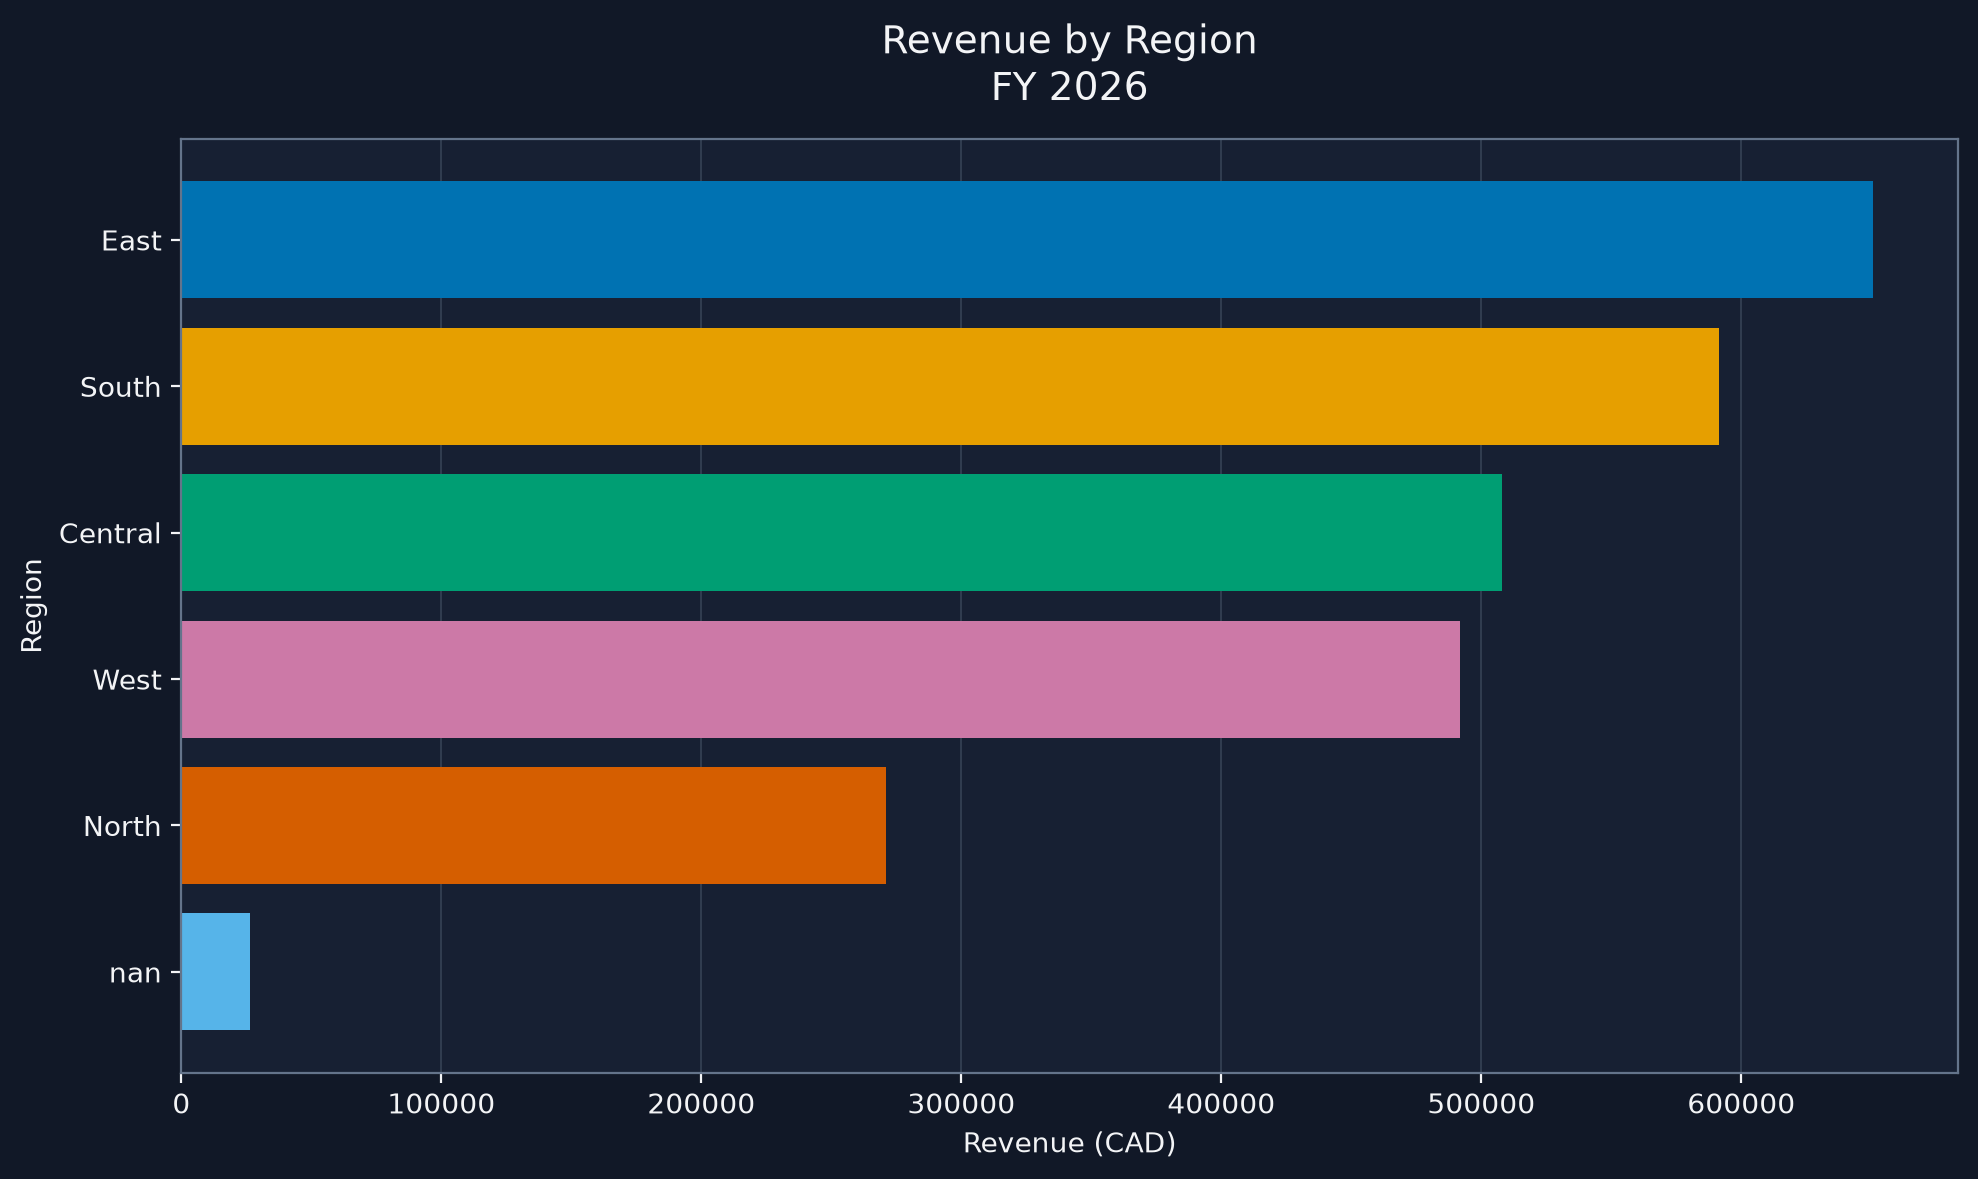


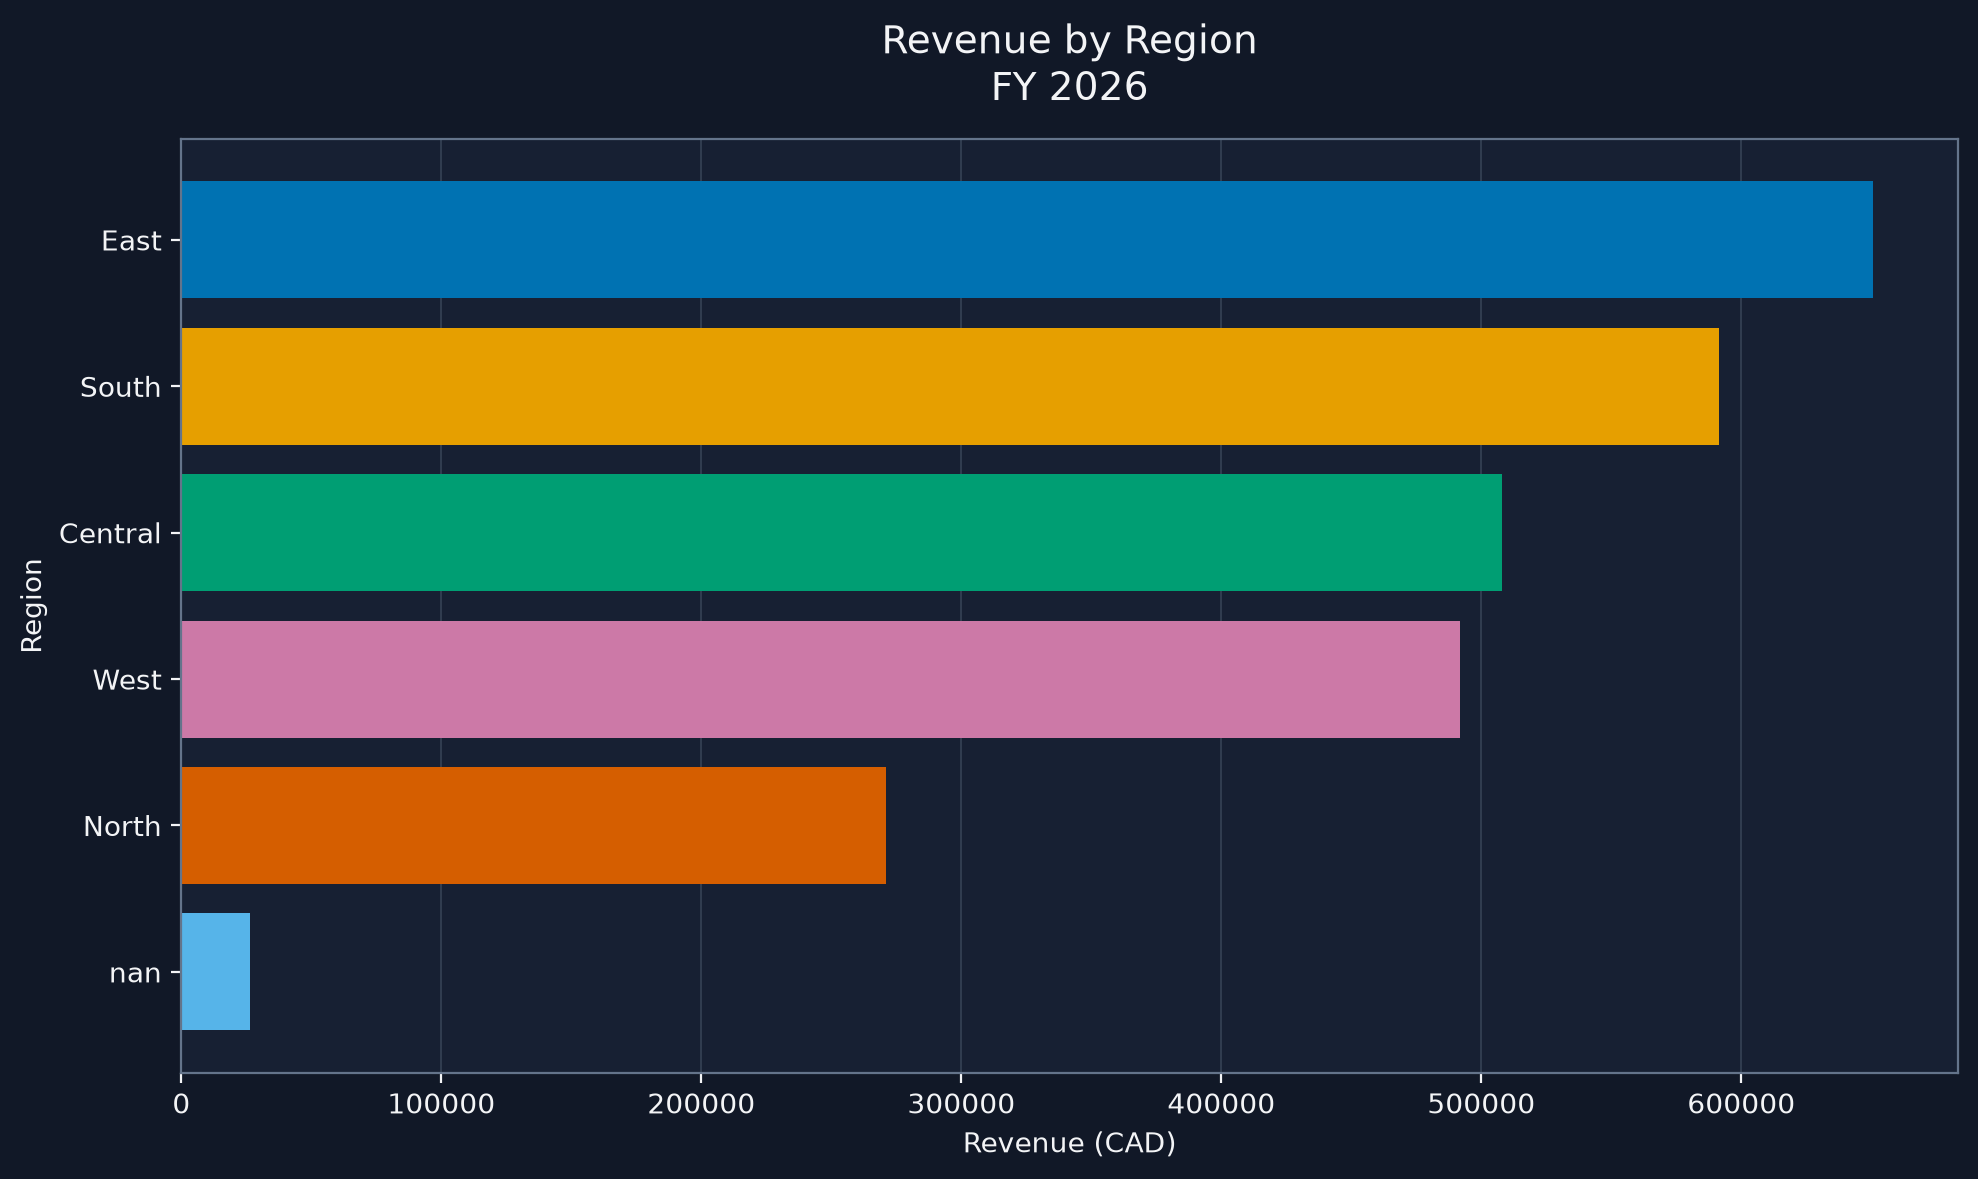

PosixPath('/Users/admin/Desktop/Auto DQ/autodq-analytics/notebooks/revenue.png')

In [74]:
report = project.visualize(
    chart="bar",
    x="Region",
    y="Revenue",
    title="Revenue by Region",
    subtitle="FY 2026",
    x_label="Region",
    y_label="Revenue (CAD)",
    theme="dark",
    palette="colorblind",
    figsize=(10, 6),
    dpi=200,
    grid=True,
    legend=False,
)

chart = report.latest
chart.show()
chart.save("revenue.png")